<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/08_Lab_CNN_Ising_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes neuronales convolucionales

In [1]:
import numpy as np
import matplotlib.pylab as plt
import sympy as sp
import scipy as sc
#import tensorflow as tf
#https://setosa.io/ev/image-kernels/

In [2]:
%pip show torch

Name: torch
Version: 2.14.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: 
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: 
Location: c:\CCA\005_CCA_Estudiantes\Laboratorios\01_LabPatronesAgente\Tools\.venv\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: ogb, pytorch-lightning, torchmetrics
Note: you may need to restart the kernel to use updated packages.


In [3]:
12*1+2*1*1+12*-1+-1+-1

0

# Convolución
![convolucion](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/convolution.png?raw=true)




1. Dada una imagen  :

```
M = array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0]])
```
Apliquemos un filtro
```
filter = array([[ 1,  0, -1],
       [ 1,  0, -1],
       [ 1,  0, -1]])
```

Y construyamos la operacion de convolucion

Results = M * Filter

```
Results = array([[ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0],
       [ 0, 30, 30,  0]])
  ```


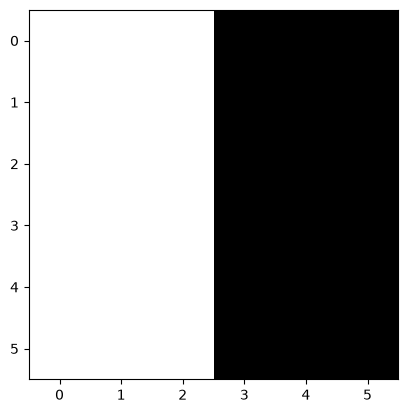

In [4]:
#Construyamos una imagen de negros y blancos
V = np.array([10,10,10,0,0,0])
Img = np.tile(V,6).reshape(6,6) # Toma el arreglo y lo repite 6 veces seguidas pegándolo todo en una sola fila larga de 36 números. Luego con reshape, toma toma esos 36 números y los "dobla" para formar una matriz de 6 filas × 6 columnas
Img
plt.imshow(Img, cmap="gray")

 Detectemos los bordes con un filtro vertical
```
A = [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
 ```

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


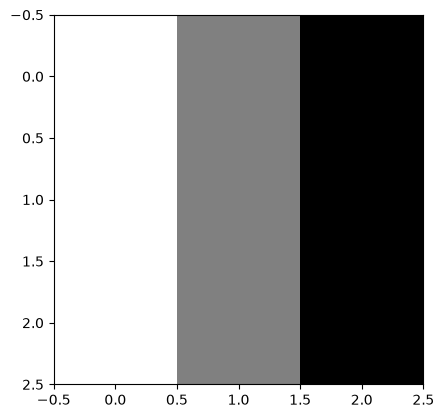

In [5]:
F = np.array([1,0,-1])
filter = np.tile(F,3).reshape(3,3)
print(filter)
plt.imshow(filter, cmap="gray")


La operación de convolución, permite construir una nueva matrix en la que se puede indentificar los bordes.

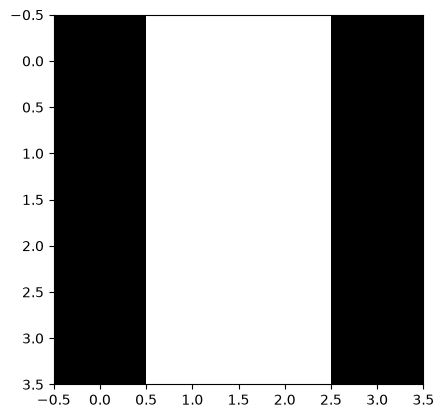

In [6]:
from scipy import signal
#new_img = np.convolve(Img, filter)
#mode="valid" es la opción que permite calcular en las posiciones donde el filtro cabe completo dentro de la imagen
# el valor absoluto asegura que cualquier borde (sin importar el signo que le dio la rotación del filtro) se vea brillante; las zonas sin cambio (valor 0) se ven negras.
new_img = signal.convolve2d(Img, filter,mode="valid")
abs(new_img)
plt.figure()
plt.imshow(abs(new_img), cmap="gray")
plt.show()


In [7]:
new_img

array([[  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0],
       [  0, -30, -30,   0]])

In [ ]:
# in_img  = tf.constant(Img)
# filter_img  = tf.constant(filter)
# tf.nn.conv2d(in_img, filter_img,padding='VALID')

Apliquemos un filtro horizontal

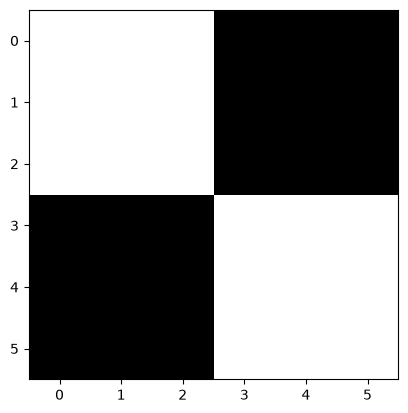

In [8]:
M = np.array([[10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [10, 10, 10,  0,  0,  0],
       [0, 0, 0,  10,  10,  10],
       [0, 0, 0,  10,  10,  10],
       [0, 0, 0,  10,  10,  10]])

plt.imshow(M, cmap="gray")

In [9]:
sp.Matrix(M)

Matrix([
[10, 10, 10,  0,  0,  0],
[10, 10, 10,  0,  0,  0],
[10, 10, 10,  0,  0,  0],
[ 0,  0,  0, 10, 10, 10],
[ 0,  0,  0, 10, 10, 10],
[ 0,  0,  0, 10, 10, 10]])

Matrix([
[ 1,  1,  1],
[ 0,  0,  0],
[-1, -1, -1]])

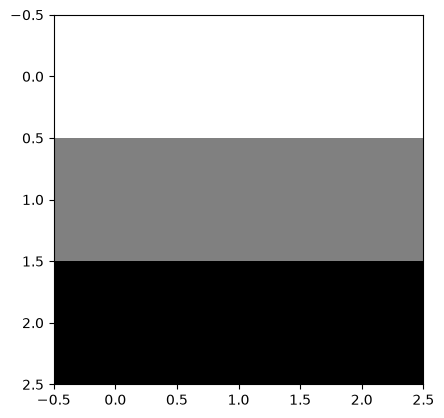

In [10]:
F = np.array([1,0,-1])
filter = np.tile(F,3).reshape(3,3)
filter=filter.T
#print(filter)
plt.imshow(filter, cmap="gray")
sp.Matrix(filter)

[[  0   0   0   0]
 [-30 -10  10  30]
 [-30 -10  10  30]
 [  0   0   0   0]]


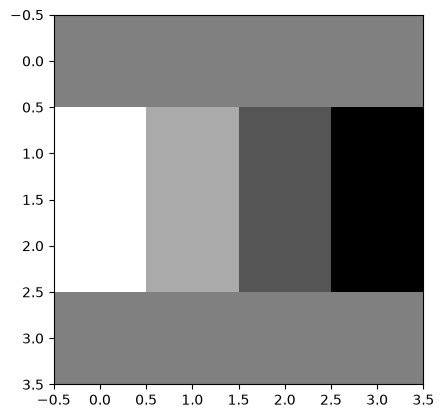

Matrix([
[ 0,  0,   0,   0],
[30, 10, -10, -30],
[30, 10, -10, -30],
[ 0,  0,   0,   0]])

In [11]:
new_img = signal.convolve2d(M,filter,mode="valid")
print(new_img)
plt.figure()
plt.imshow(-new_img, cmap="gray")
plt.show()
sp.Matrix(-new_img)


Existen otro tipo de filtros que pueden ser empleados.

- [Sobel filter](https://en.wikipedia.org/wiki/Sobel_operator)
  ```
  filter = array([[ 1,  0, -1],
       [ 2,  0, -2],
       [ 1,  0, -1]])
```
- Scharr Filter
```
filter = array([[ 3,  0, -3],
       [ 10,  0, -10],
       [ 3,  0, -3]])
```

¿Cómo elegir los parametros del filtro para detectar otro tipo de bordes?
```
filter = array([[ w1,  w2, w3],
     [ w4,  w5, w6],
     [ w7,  w8, w9]])
```

# Padding

El padding permite que la imagen resultante, sea del mismo tamaño que la original. Dada una matrix $n \times n$ asociada a una imagen y aplicada un filtro de rango $f\times f$ la operación después de la convolución es de rango $(n-f+1) \times (n-f+1)$.

Para garantizar que se tenga una imagen con el mismo tamaño de la original se aplica el padding



Para un padding de 1,tenemos entonces la siguientes dimensiones:

###  input = (n)x(n)


![input](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/input.png?raw=true)


### filter = fxf

![filter](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/filter.png?raw=true)



###  Output = (n-f+1)x(n-f+1)


![Output](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/output.png?raw=true)

--------------------------------------------------------------

 ### input con padding = (n+2p)x(n+2p)
![padding](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/padding.png?raw=true)



### filter = fxf

![filter](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/filter.png?raw=true)


###  Output = (n+2p-f+1)x(n+2p-f+1)




## Valid Padding

  - nxn * fxf ---> n-f+1

## Same Padding
The output size is the same that the input size

- n+2pxn+2p * fxf ---> n-f+1+2p x n-f+1+2p


# Stride

Salto entre valores de la imagen para hacer la convolución, en la siguiente imagen se muestra un stride de s=2.

Input : 6x6 = nxn

Filter : 3x3 = fxf

Results = Input * Filter

Results: (6-3)/2--->2x2

$\left[ \frac{n+2*p-f}{s}+1 \right] \times \left[ \frac{n+2*p-f}{s}+1 \right]$

[] operation floor


![stride](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/stride.png?raw=true)




# Convolución sobre todo el volumen:

![volumen](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/rgb_volume.png?raw=true)


## Multiples filtros sobre el volumen:


![multiples filtros](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/convolution_img/rgb_two_filter.png?raw=true)

Input= nxnxnc

Filter= fxfxnc

Output= n-f+1 x  n-f+1  x n'c

nc= numero de canales

n'c= el numero de filtros





REf: https://towardsdatascience.com/beginners-guide-to-understanding-convolutional-neural-networks-ae9ed58bb17d


# Clasificación de fases del modelo de Ising con una red convolucional (Keras)

Este laboratorio es análogo a `07_Lab_NN_IsingV2` (donde construimos un MLP), pero ahora usamos **Keras** — una API de más alto nivel — y una **red convolucional (CNN)** en lugar de un perceptrón multicapa.

Vamos a:

1. Hacer una introducción breve a Keras.
2. Cargar las configuraciones de espines del modelo de Ising (`Datos/ising_dataset.npz`).
3. Construir y entrenar una CNN simple que clasifique cada configuración como fase **ordenada** o **desordenada**.
4. Evaluarla sobre un barrido fino de temperaturas (`Datos/temperatura_critica.npz`) para **estimar la temperatura crítica** $T_c$ a partir de dónde la red cambia de opinión.
5. Bonus: usar la misma red, sin reentrenar, sobre configuraciones de **otro tamaño de red** ($L=20$, `Datos/temperatura_critica20.npz`).

## 0. ¿Qué es Keras?

**Keras** es una API de alto nivel para construir y entrenar redes neuronales. Desde la versión 3, Keras es *multi-backend*: el mismo código (`keras.layers`, `keras.Model`, `.compile()`, `.fit()`, ...) puede ejecutarse sobre **TensorFlow**, **JAX** o **PyTorch** como motor de cómputo. El backend se elige con la variable de entorno `KERAS_BACKEND` **antes** de importar `keras`; el resto del notebook no depende de cuál se use.

Comparado con lo que se hace  "a mano" en PyTorch, Keras encapsula el ciclo de entrenamiento:

| PyTorch (manual)                                              | Keras (equivalente)                    |
|---|---|
| Definir `Dataset` + `DataLoader`                               | Pasar arreglos de NumPy directamente a `.fit()` |
| Escribir el bucle `for epoch ... for batch ...`                | `model.fit(X, y, epochs=..., batch_size=...)` |
| `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` | Ocurre internamente en `.fit()`        |
| Guardar el mejor modelo con un `if val_loss < best_val_loss`   | Callback `keras.callbacks.ModelCheckpoint` |
| `model.eval()` + `torch.no_grad()` + bucle manual              | `model.evaluate(X, y)` / `model.predict(X)` |

Un modelo en Keras se arma apilando **capas** (`keras.layers`) dentro de un `keras.Sequential` (o la API funcional para arquitecturas más complejas), se **compila** indicando optimizador, función de pérdida y métricas, y se **entrena** con `.fit()`.

In [12]:
!pip install keras


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install jax


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
#os.environ.setdefault("KERAS_BACKEND", "jax")  # TensorFlow, JAX o PyTorch: el código de Keras no cambia
os.environ.setdefault("KERAS_BACKEND", "torch")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Keras:", keras.__version__)
print("Backend:", keras.backend.backend())

Keras: 3.15.1
Backend: torch


## 1. Datos: configuraciones de espines del modelo de Ising

Reutilizamos el dataset generado en `07_Lab_NN_IsingV2` (ver `07_bDatos_Ising.ipynb` para el detalle de cómo se generó). Cada configuración es una matriz $L\times L$ de espines $\pm 1$, etiquetada según su temperatura respecto a $T_c$:

| | fase **ordenada** (`y = 0`) | fase **desordenada** (`y = 1`) |
|---|---|---|
| temperatura | $T < T_c$ | $T > T_c$ |
| aspecto | un dominio grande domina la red | "ruido", sin dominios |

`ising_dataset.npz` **excluye** una banda alrededor de $T_c$ a propósito, para que las etiquetas sean inequívocas durante el entrenamiento.

In [15]:
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)

X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]
Tc_onsager = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)
print("Temperaturas:", np.unique(T))
print("Realizaciones:", np.unique(realizacion))
print(f"L = {L}   Tc (Onsager) = {Tc_onsager:.4f}")

X: (1600, 16, 16) int8
y: (1600,) int8
Temperaturas: [1.2   1.375 1.55  1.725 1.9   2.6   2.825 3.05  3.275 3.5  ]
Realizaciones: [0 1 2 3]
L = 16   Tc (Onsager) = 2.2692


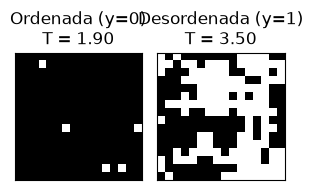

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(3, 3))
# Encontrar un ejemplo de cada clase
idx_ordenada = np.where(y == 0)[0][0]
idx_desordenada = np.where(y == 1)[0][0]

# Dibujar los dos ejemplos
for ax, idx, titulo in zip(
    axes,
    [idx_ordenada, idx_desordenada],
    [f"Ordenada (y=0)\nT = {T[idx_ordenada]:.2f}", f"Desordenada (y=1)\nT = {T[idx_desordenada]:.2f}"],
):
    ax.imshow(X[idx], cmap="gray", vmin=-1, vmax=1)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 2. Preparación de los datos para Keras

Igual que en el notebook de PyTorch, usamos el campo `realizacion` (cadena de Monte Carlo independiente) para separar train/val/test, evitando que configuraciones muy correlacionadas de una misma cadena aparezcan en más de un conjunto:

- `realizacion` 0 y 1 → entrenamiento
- `realizacion` 2 → validación
- `realizacion` 3 → test

A diferencia del MLP (que aplanaba cada configuración a un vector de 256 valores), una CNN espera imágenes con forma `(alto, ancho, canales)`. Como tenemos un solo canal (el espín), reformamos cada configuración a `(L, L, 1)`. No hace falta convertir nada a tensores de PyTorch ni armar `DataLoader`s: Keras trabaja directamente con arreglos de NumPy.

In [17]:
# mask_train: True en las posiciones donde 'realizacion' es 0 o 1
mask_train = np.isin(realizacion, [0, 1])
# mask_val: True solo donde 'realizacion' es 2
mask_val = realizacion == 2
# mask_test: True solo donde 'realizacion' es 3
mask_test = realizacion == 3


# Dado un arreglo booleano (mask), filtra X, y, T quedándose solo con las posiciones marcadas True, y deja X lista para la CNN.
def preparar(mask):
    X_ = X[mask].astype("float32").reshape(-1, L, L, 1)
    y_ = y[mask].astype("float32")
    T_ = T[mask]
    return X_, y_, T_

X_train, y_train, T_train = preparar(mask_train)
X_val, y_val, T_val = preparar(mask_val)
X_test, y_test, T_test = preparar(mask_test)

print("Train:", X_train.shape, y_train.shape) # Datos con realizaciones 0 y 1
print("Val:  ", X_val.shape, y_val.shape)     # Datos con realización 2
print("Test: ", X_test.shape, y_test.shape)   # Datos con realización 3

Train: (800, 16, 16, 1) (800,)
Val:   (400, 16, 16, 1) (400,)
Test:  (400, 16, 16, 1) (400,)


## 3. Arquitectura: red convolucional simple

Una CNN es una elección natural para este problema: la fase de una configuración es una propiedad **estadística y global** (¿hay dominios grandes o no?), no depende de *dónde* aparezcan los dominios. Los filtros convolucionales detectan patrones locales (espines alineados con sus vecinos) **sin importar la posición**, exactamente la invariancia que necesitamos.

Arquitectura (deliberadamente simple):

- `Conv2D(8, 3x3) + ReLU` — detecta patrones locales de alineación.
- `MaxPooling2D(2x2)` — reduce la resolución espacial.
- `Conv2D(16, 3x3) + ReLU` — combina patrones locales en patrones un poco más grandes.
- `GlobalAveragePooling2D` — en vez de aplanar (`Flatten`) y usar una capa densa grande, promediamos cada mapa de activación sobre todo el espacio. Esto produce un vector de tamaño fijo **sin importar el tamaño $L\times L$ de la entrada**: la misma red podrá evaluarse más adelante sobre configuraciones de otro tamaño de red, algo que el MLP (con su entrada aplanada de tamaño fijo) no puede hacer.
- `Dense(16) + ReLU` y `Dense(1) + sigmoide` — combinan las características globales en una probabilidad de fase desordenada.

Para permitir tamaños de entrada variables declaramos `Input(shape=(None, None, 1))`.

In [18]:
keras.utils.set_random_seed(42) # Se fijan los pesos de la red. Arrancan con valores aleatorios antes de entrenar

# Armar la red apilando las capas en el orden descrito
model = keras.Sequential(
    [
        keras.Input(shape=(None, None, 1)),
        layers.Conv2D(8, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ising_cnn",
)

model.summary()

Model: "ising_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, None, None, 8)  │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, None, None, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 16) │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compilación y entrenamiento

`compile()` fija el optimizador, la función de pérdida y las métricas a reportar. Como la última capa ya tiene activación sigmoide (produce una probabilidad), usamos `binary_crossentropy` directamente (en PyTorch usamos `BCEWithLogitsLoss` porque la red devolvía *logits*, no probabilidades).

El callback `ModelCheckpoint` guarda automáticamente los pesos con menor `val_loss`, reemplazando el bloque manual `if val_loss < best_val_loss: ...` del notebook de PyTorch.

In [19]:
%pip show torch

Name: torch
Version: 2.14.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: 
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: 
Location: c:\CCA\005_CCA_Estudiantes\Laboratorios\01_LabPatronesAgente\Tools\.venv\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: ogb, pytorch-lightning, torchmetrics
Note: you may need to restart the kernel to use updated packages.


In [62]:
# compile() define CÓMO se va a entrenar: qué optimizador usar, qué pérdida
# minimizar, y qué métricas reportar (para monitorear, no para entrenar).
model.compile(
    # Adam es un algoritmo de descenso de gradiente (una versión mejor
    # que el "gradiente simple"; ajusta el tamaño del paso por sí solo, por parámetro).
    # learning_rate=1e-3 (=0.001): qué tan grande es cada paso de ajuste de pesos.
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # La función de error a minimizar
    loss="binary_crossentropy",
    # Métrica adicional que se calcula e imprime en cada época, solo para visualizarla
    
    metrics=["accuracy"],
)

# Configura el callback que guarda automáticamente el mejor modelo visto hasta ahora.
checkpoint = keras.callbacks.ModelCheckpoint(
    "best_ising_cnn.keras",      # nombre del archivo donde se guardan los pesos
    monitor="val_loss",          # qué métrica vigilar para decidir "mejor"
    save_best_only=True,         # solo sobrescribe el archivo si val_loss mejoró
                                  # (si empeora respecto a la época anterior, no guarda nada nuevo)
)

# model.fit() es el entrenamiento real — el equivalente al doble bucle
# "for epoch... for batch..." que escribías a mano en PyTorch.
historia = model.fit(
    X_train, y_train,                  # datos de entrenamiento (entrada y etiquetas)
    validation_data=(X_val, y_val),    # datos de validación: se evalúan cada época
                                        # (no se usan para ajustar pesos, solo para medir
                                        # qué tan bien generaliza — y para que ModelCheckpoint decida)
    epochs=20,                         # 20 pasadas completas por todo X_train
    batch_size=32,                     # tamaño de cada lote 
    callbacks=[checkpoint],            # conecta el guardado automático definido arriba
    verbose=2,                         # qué tanto imprime en pantalla:
                                        # 2 = una línea de texto por época (sin barra de progreso)
)
# 'historia' guarda, por cada época, el valor de loss/accuracy (train y val) —


Epoch 1/20
25/25 - 1s - 20ms/step - accuracy: 0.7250 - loss: 0.6354 - val_accuracy: 0.7325 - val_loss: 0.5686
Epoch 2/20
25/25 - 0s - 19ms/step - accuracy: 0.9350 - loss: 0.4767 - val_accuracy: 0.9950 - val_loss: 0.3655
Epoch 3/20
25/25 - 0s - 18ms/step - accuracy: 0.9975 - loss: 0.2472 - val_accuracy: 0.9975 - val_loss: 0.1417
Epoch 4/20
25/25 - 0s - 18ms/step - accuracy: 1.0000 - loss: 0.0875 - val_accuracy: 0.9975 - val_loss: 0.0508
Epoch 5/20
25/25 - 0s - 17ms/step - accuracy: 1.0000 - loss: 0.0349 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 6/20
25/25 - 0s - 17ms/step - accuracy: 1.0000 - loss: 0.0195 - val_accuracy: 0.9975 - val_loss: 0.0178
Epoch 7/20
25/25 - 0s - 17ms/step - accuracy: 0.9987 - loss: 0.0132 - val_accuracy: 1.0000 - val_loss: 0.0135
Epoch 8/20
25/25 - 0s - 18ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0107
Epoch 9/20
25/25 - 0s - 18ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 10/2

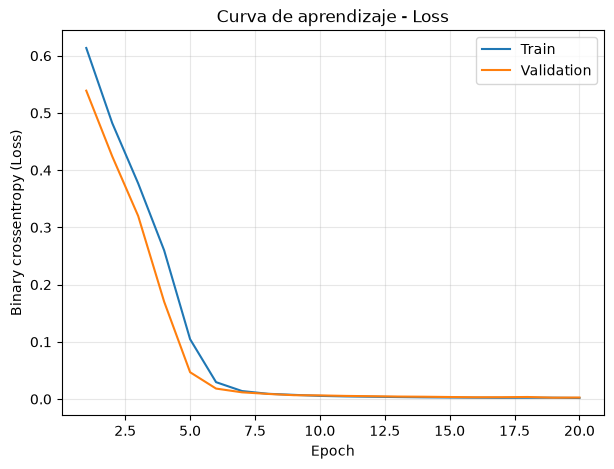

In [21]:
epochs_range = range(1, len(historia.history["loss"]) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs_range, historia.history["loss"], label="Train")
plt.plot(epochs_range, historia.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Binary crossentropy (Loss)")
plt.title("Curva de aprendizaje - Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Se observa que durante las primeras épocas de entrenamiento, el loss en bastante alto, indicando que el modelo predice mal al inicio.
Adicionalmente, se observa que los datos de validación muestran ligeramente un menor valor del loss y siguen una misma tendencia que los datos de entrenamiento.

Si por otro ladoo la curva de train siguiera bajando mientras la de validation se quedara alta o empezara a subir, sería señal de overfitting dado que la red estaría memorizando los datos de entrenamiento en vez de aprender el patrón general.

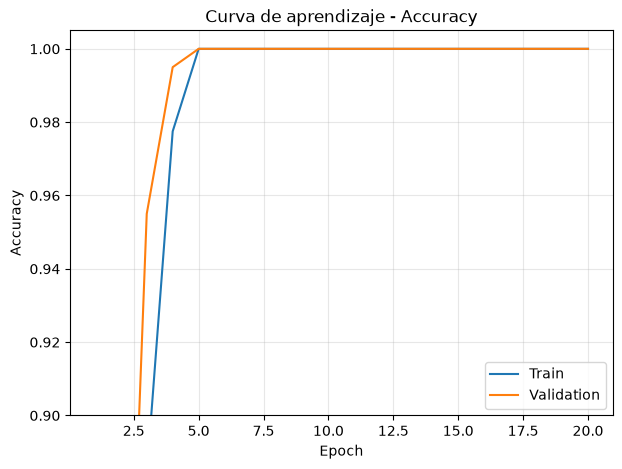

In [22]:
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, historia.history["accuracy"], label="Train")
plt.plot(epochs_range, historia.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0.9, 1.005)
plt.show()

Recordando que Accuracy representa la proporción de ejemplos clasificados correctamente (1.00 = 100% acierto), se puede observar que durante las épocas 1-2, la accuracy es mucho menor a 0.9, lo que indicaría que el modelo no está logrando predecir bien. Luego, alrededor de las épocas 2-5, hay una subida del accuracy, la cual se respalda con lo que se vió anteriormente en la caída de la curva de loss. Finalmente, a partir de la época 5, ambas curvas llegan al 100% de aciertos de forma estable

## 5. Evaluación en el conjunto de test

In [23]:
# Carga desde disco el archivo que guardó el ModelCheckpoint durante el entrenamiento. Se carga específicamente específicamente la mejor versión guardada.
model = keras.models.load_model("best_ising_cnn.keras")

# evaluate() hace lo mismo que la parte de "validación" de cada epoch durante el entrenamiento: una sola pasada hacia adelante (sin actualizar pesos) sobre
# X_test/y_test, y devuelve (loss, accuracy) en ese orden.
# Recordar que X_test es el conjunto de la "realización" 3, que el modelo no ha visto
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss:     {test_loss:.5f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.00207
Test accuracy: 1.0000


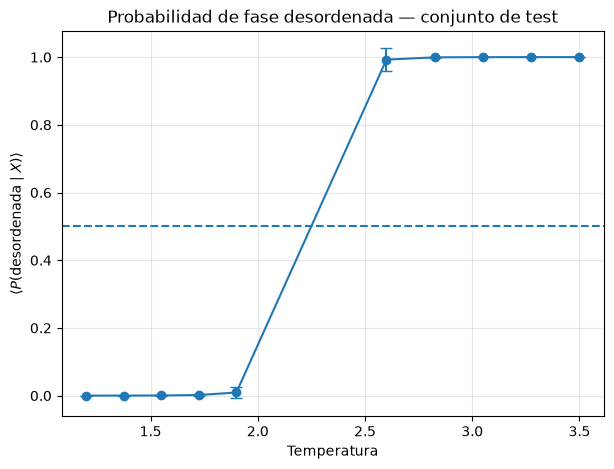

In [24]:
# model.predict() devuelve, para cada configuración de espines en X_test, la probabilidad de que sea "desordenada"
# .ravel lo aplana, verbose= 0 controla cuanto texto imprime Keras en una barra de progreso. En este caso =0 no imprime nada
probs_test = model.predict(X_test, verbose=0).ravel()


# T_test tiene UNA temperatura por cada configuración (muchas configuraciones repiten la misma T)
unique_T_test = np.unique(T_test) #saca la lista de temperaturas distintas, sin repetir
mean_p, std_p = [], []
for temp in unique_T_test:
    mask = T_test == temp # mask: True en las posiciones donde la temperatura es exactamente "temp"
    mean_p.append(probs_test[mask].mean())     # promedio de las probabilidades predichas, SOLO entre las configuraciones que tienen esa temperatura
    std_p.append(probs_test[mask].std())       # qué tan dispersas están esas probabilidades
mean_p, std_p = np.array(mean_p), np.array(std_p)

plt.figure(figsize=(7, 5))
plt.errorbar(unique_T_test, mean_p, yerr=std_p, fmt="o-", capsize=4)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada} \mid X)\rangle$")
plt.title("Probabilidad de fase desordenada — conjunto de test")
plt.grid(alpha=0.3)
plt.show()

- Para T < ~2.0: la curva está pegada a 0, con barras de error pequeñas. Indica que la red está muy segura de que son configuraciones ordenadas, y coincide en casi todas las configuraciones a esa T, por esta razón el std es bajo.

- Entre T ≈ 2.0 y T ≈ 2.6 se observa una transición abrupta, la curva sube de 0 a 1 en un rango de temperatura muy angosto. Aquí el error es mas grande porque configuraciones a esa misma T a veces se ven más ordenadas y a veces más desordenadas.

- Para T > 2.6: la curva se queda en 1.0, indicando total seguridad de fase desordenada.

## 6. Barrido cerca de la temperatura crítica

`ising_dataset.npz` deja fuera a propósito una banda alrededor de $T_c$. `temperatura_critica.npz` es el conjunto contrario: un barrido fino que **sí incluye** la zona crítica, con varias realizaciones independientes. Aquí no hay etiqueta de entrenamiento confiable — la idea es que, si la red aprendió a reconocer fases, su probabilidad promedio $\langle P(\mathrm{desordenada}\mid T)\rangle$ pase de 0 a 1 alrededor de la verdadera $T_c$, y podamos **estimar $T_c$ como el punto donde esa curva cruza 0.5**.

In [25]:
datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)

X_tc = datos_tc["X"].astype("float32").reshape(-1, L, L, 1) # Nuevamente reorganiza los datos en 4 dimensiones: (número de configuraciones, alto, ancho, canales). El -1 significa calcula ese número automáticamente, para que cuadre con la cantidad total de datos
T_tc = datos_tc["T"]
realizacion_tc = datos_tc["realizacion"]

print("X_tc:", X_tc.shape)
print("Temperaturas:", np.unique(T_tc))
print("Realizaciones:", np.unique(realizacion_tc))

X_tc: (6200, 16, 16, 1)
Temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
Realizaciones: [0 1 2 3]


In [26]:
# Usar modelo con las nuevas temperaturas. Carga los mejores pesos guardados durante el entrenamiento
probs_tc = model.predict(X_tc, verbose=0).ravel()
pred_tc = (probs_tc >= 0.5).astype(int) # Convierte cada probabilidad en una decisión binaria (0 o 1). Si prob >= 0.5 → predice "desordenada" (1); si no → "ordenada" (0)

#print(pred_tc)
df = pd.DataFrame({
    "T": T_tc,
    "realizacion": realizacion_tc,
    "probabilidad": probs_tc,
    "prediccion": pred_tc,
})

resumen = (
    df.groupby(["realizacion", "T"]).agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"), N=("prediccion", "size")).reset_index()
)
#
resumen.head(-5)

,realizacion,T,prob_media,prob_std,N
0,0,1.600,0.000283,0.000262,50
1,0,1.700,0.001030,0.002253,50
2,0,1.800,0.002267,0.004859,50
3,0,1.900,0.004480,0.009502,50
4,0,2.000,0.022155,0.044996,50
...,...,...,...,...,...
114,3,2.450,0.932280,0.154094,50
115,3,2.475,0.943793,0.167816,50
116,3,2.500,0.977145,0.092132,50
117,3,2.600,0.989219,0.028503,50


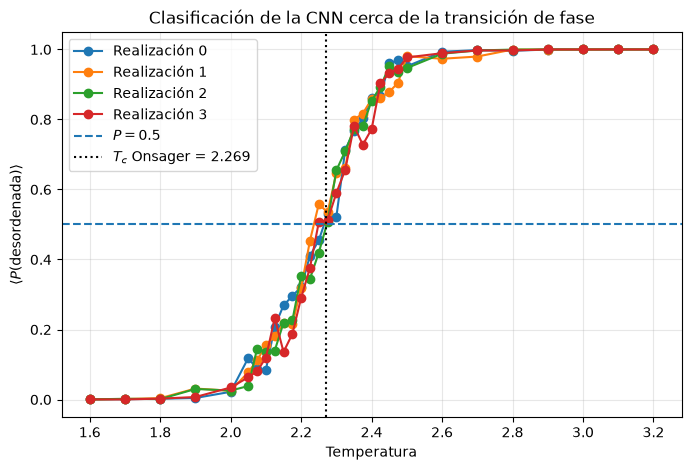

In [27]:
plt.figure(figsize=(8, 5))

# Graficar probabilidades por realización
for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r] # Crea columna de True o False en donde la realización es r, y luego resumen[...] se queda solo con las filas donde el valor es true
                                                   # resumen[...] filtra filas, resumen["T"] filtra columnas
    plt.plot(datos_r["T"], datos_r["prob_media"], "o-", label=f"Realización {r}")

plt.axhline(0.5, linestyle="--", label=r"$P=0.5$")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Clasificación de la CNN cerca de la transición de fase")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
Tc_estimadas = []

for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r].sort_values("T") # Se queda con las filas con realización r y luego se queda con todas las columnas. Organiza los datos de menor a mayor temperatura.
    temps = datos_r["T"].to_numpy()
    probs = datos_r["prob_media"].to_numpy()

    for i in range(len(temps) - 1):
        p1, p2 = probs[i], probs[i + 1]
        if p1 <= 0.5 <= p2:
            T1, T2 = temps[i], temps[i + 1]
            Tc_r = T1 + (0.5 - p1) * (T2 - T1) / (p2 - p1)  # interpolación lineal
            Tc_estimadas.append(Tc_r)
            print(f"Realización {r}: Tc_CNN = {Tc_r:.4f}")
            break

Tc_estimadas = np.array(Tc_estimadas)
Tc_mean = Tc_estimadas.mean()
Tc_std = Tc_estimadas.std(ddof=1)

print()
print(f"Tc_CNN promedio = {Tc_mean:.4f} +/- {Tc_std:.4f}")
print(f"Tc Onsager      = {Tc_onsager:.4f}")

Realización 0: Tc_CNN = 2.2652
Realización 1: Tc_CNN = 2.2361
Realización 2: Tc_CNN = 2.2727
Realización 3: Tc_CNN = 2.2488

Tc_CNN promedio = 2.2557 +/- 0.0165
Tc Onsager      = 2.2692


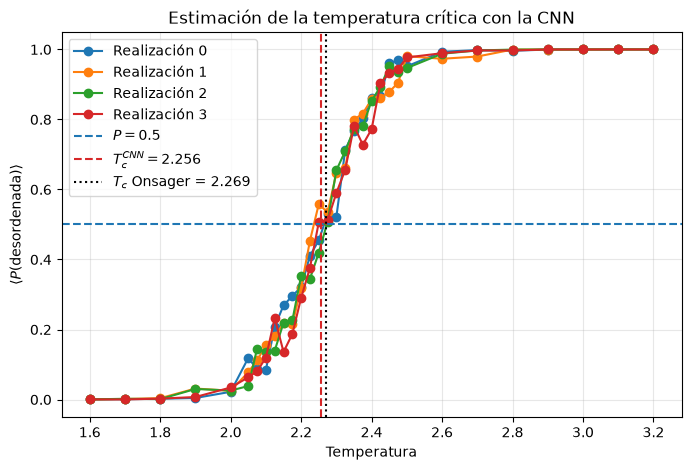

In [29]:
plt.figure(figsize=(8, 5))

for r in np.unique(realizacion_tc):
    datos_r = resumen[resumen["realizacion"] == r]
    plt.plot(datos_r["T"], datos_r["prob_media"], "o-", label=f"Realización {r}")

plt.axhline(0.5, linestyle="--", label=r"$P=0.5$")
plt.axvline(Tc_mean, linestyle="--", color="C3", label=fr"$T_c^{{CNN}} = {Tc_mean:.3f}$")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Estimación de la temperatura crítica con la CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Bonus: generalización a otro tamaño de red ($L=20$)

`GlobalAveragePooling2D` hace que la red no tenga ningún peso atado a un tamaño de entrada específico. Podemos entonces tomar exactamente el mismo modelo, **sin reentrenar**, y evaluarlo sobre `temperatura_critica20.npz` (configuraciones $20\times 20$, con la misma $T_c$ física). Con un MLP de entrada aplanada esto sería imposible sin cambiar la arquitectura.

In [30]:
# Carga un dataset nuevo, con configuraciones de L=20 (en vez de L=16). El tamaño L viene guardado dentro del propio archivo (por si acaso)
datos_tc20 = np.load("Datos/temperatura_critica20.npz", allow_pickle=False)
L20 = int(datos_tc20["L"])


X_tc20 = datos_tc20["X"].astype("float32").reshape(-1, L20, L20, 1)
T_tc20 = datos_tc20["T"]
realizacion_tc20 = datos_tc20["realizacion"]

print(f"L = {L20}   X_tc20: {X_tc20.shape}")

# Se usa el MISMO modelo, entrenado únicamente con grillas de 16x16, para predecir sobre configuraciones de 20x20, sin reentrenar nada
probs_tc20 = model.predict(X_tc20, verbose=0).ravel()

df20 = pd.DataFrame({
    "T": T_tc20,
    "realizacion": realizacion_tc20,
    "probabilidad": probs_tc20,
})

resumen20 = (
    df20.groupby("T")
        .agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"))
        .reset_index()
)
df20

L = 20   X_tc20: (6200, 20, 20, 1)


,T,realizacion,probabilidad
0,3.2,0,0.999989
1,3.2,0,0.999995
2,3.2,0,0.999990
3,3.2,0,0.999998
4,3.2,0,0.999968
...,...,...,...
6195,1.6,3,0.000116
6196,1.6,3,0.000390
6197,1.6,3,0.000111
6198,1.6,3,0.000061


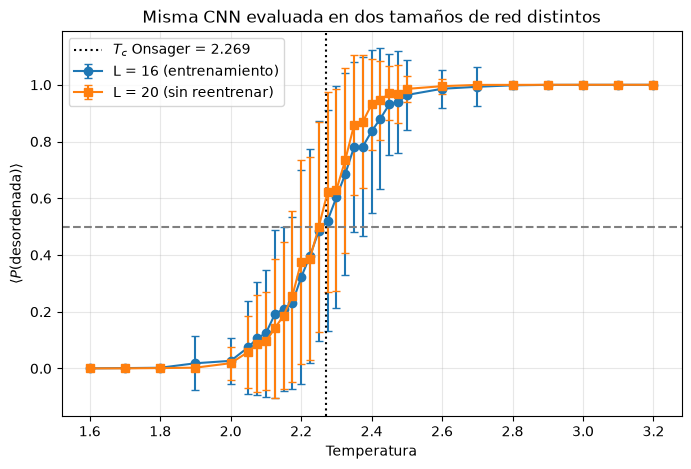

In [31]:
resumen16 = (
    df.groupby("T")
      .agg(prob_media=("probabilidad", "mean"), prob_std=("probabilidad", "std"))
      .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(resumen16["T"], resumen16["prob_media"], yerr=resumen16["prob_std"],
             fmt="o-", capsize=3, label=f"L = {L} (entrenamiento)")
plt.errorbar(resumen20["T"], resumen20["prob_media"], yerr=resumen20["prob_std"],
             fmt="s-", capsize=3, label=f"L = {L20} (sin reentrenar)")

plt.axhline(0.5, linestyle="--", color="gray")
plt.axvline(Tc_onsager, linestyle=":", color="k", label=fr"$T_c$ Onsager = {Tc_onsager:.3f}")

plt.xlabel("Temperatura")
plt.ylabel(r"$\langle P(\mathrm{desordenada})\rangle$")
plt.title("Misma CNN evaluada en dos tamaños de red distintos")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Para una red más grande ($L=20$) se espera que la transición se vea **más abrupta** (más cercana al límite termodinámico, donde la transición de fase es discontinua), mientras que en $L=16$ el efecto de tamaño finito la suaviza un poco. Aun así, la misma CNN — sin ver un solo ejemplo de $L=20$ durante el entrenamiento — debería ubicar el cruce cerca de $T_c$.


- Keras permite construir y entrenar la misma clase de clasificador que hicimos con PyTorch en muchas menos líneas: no hay bucle de entrenamiento manual, `DataLoader` ni manejo explícito del dispositivo.
- Una CNN simple (dos capas convolucionales + *global average pooling*) alcanza una exactitud muy alta separando fase ordenada vs. desordenada lejos de $T_c$.
- Evaluando la red sobre el barrido fino de temperaturas, la probabilidad de fase desordenada cruza $0.5$ muy cerca de la $T_c$ de Onsager, sin que la red haya visto nunca esa temperatura durante el entrenamiento.
- Gracias a `GlobalAveragePooling2D`, la arquitectura no depende del tamaño $L\times L$ de la red de espines, lo que permite reutilizar el mismo modelo entrenado sobre configuraciones de otro tamaño — algo que un MLP con entrada aplanada no puede hacer sin cambiar de arquitectura.

# Laboratorio: interpreta la red, no solo confíes en ella

La CNN clasifica fases con exactitud casi perfecta y ubica $T_c$ con buena precisión. Eso no basta: una red puede acertar por razones equivocadas (un atajo espurio en los datos, por ejemplo). Antes de dar el resultado por bueno, ábrela:

- Estudia los kernels de la primera capa convolucional. ¿Qué patrón detecta cada uno? Compáralos con un kernel de "vecinos cercanos" (como el acoplamiento del Hamiltoniano de Ising) y con un kernel de "promedio local" (un detector de magnetización). ¿Se parece alguno a estos kernels físicos, o la red encontró otra cosa?


- Analiza los mapas de activación de esos filtros sobre una configuración ordenada y una desordenada. ¿La diferencia visual que ves coincide con lo que dirías tú, a ojo, si miraras las dos configuraciones sin saber la respuesta?


- Mide qué tan sensible es la red a voltear un solo espín, lejos de $T_c$ y cerca de $T_c$. ¿Dónde es más sensible? ¿Se te ocurre una razón física para eso?

$$S(x) = \frac{1}{L^2}\sum_{i=1}^{L^2} \big|\Delta P_i(x)\big|, \qquad \Delta P_i(x) = P(\text{config. con } s_i \text{ volteado}) - P(x)$$


- Verifica si el logit ($z = Wx+b$) final es, en el fondo, una función de la magnetización. Grafica el logit contra $|m(x)|$, antes y después de entrenar. ¿La red "redescubrió" el parámetro de orden por su cuenta, o el resultado depende de trucos de la arquitectura?

## Respuestas
1. Estudiar los kernels de la primera capa convolucional.¿Qué patrón detecta cada uno? Compáralos con un kernel de "vecinos cercanos" (como el acoplamiento del Hamiltoniano de Ising) y con un kernel de "promedio local" (un detector de magnetización). ¿Se parece alguno a estos kernels físicos, o la red encontró otra cosa?

In [61]:
model = keras.Sequential(
    [
        keras.Input(shape=(None, None, 1)),
        layers.Conv2D(8, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="ising_cnn",
)
model.summary()

Model: "ising_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, None, None, 8)  │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, None, None, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, None, None, 16) │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Extraer la primera capa
layer_1 = model.layers[0]
# Extraer pesos
weights = layer_1.get_weights()
#print(weights)
#Extraer pesos de los filtros
weights_filters = weights[0]
print(weights_filters)
print(weights_filters.shape)

[[[[-0.16517518  0.0197261   0.06046039 -0.19470361  0.15581721
    -0.02320631 -0.17594156 -0.17231146]]

  [[-0.10952999  0.10892048  0.02461997  0.22130364 -0.02133062
     0.24450278  0.07769492  0.03579313]]

  [[ 0.26183903  0.03473744  0.06857622 -0.1889869  -0.06839225
     0.06307489  0.25446963 -0.00589398]]]


 [[[ 0.25355715  0.24733138  0.26650238  0.24742138 -0.15705812
     0.22227544 -0.27126184  0.12060797]]

  [[ 0.13601625  0.11617556  0.26410055  0.01098362 -0.04602483
    -0.04037572  0.10659158  0.17166409]]

  [[ 0.11817139  0.18017444  0.25517088  0.07849881  0.18503198
     0.03802258  0.02842766 -0.16432299]]]


 [[[-0.15061356 -0.04782142  0.16643941  0.23307055  0.03498137
     0.03673494  0.07839331 -0.10627517]]

  [[ 0.08279023 -0.21173583  0.15822515 -0.14961243 -0.00455329
    -0.13426626  0.26239002 -0.18429491]]

  [[-0.18941745 -0.11888398 -0.0543011  -0.02144739  0.09111556
     0.16067588  0.04729843  0.19663268]]]]
(3, 3, 1, 8)


In [34]:
# Armar el filtro 0: para esto se necesita tomar el PRIMER número de cada una de esas 9 posiciones, es decir, recorrer las 3 filas × 3 columnas, quedándome siempre con el índice 0 del último eje
# forma (3, 3, 1, 8) = (ancho, alto, canal, filtros)
Pesos_filtro_0 = []
for i in range(len(weights_filters)): # len(weights_filters) da el tamaño del primer eje (3)
    for j in range(len(weights_filters)):
        weights_filters[i] # fija el alto
        weights_filters[i][j] # fija el ancho
        weights_filters[i][j][0] # fija canal
        Pesos_filtro_0.append(weights_filters[i][j][0][0]) # fija filtro
    
print(Pesos_filtro_0)

[np.float32(-0.16517518), np.float32(-0.10952999), np.float32(0.26183903), np.float32(0.25355715), np.float32(0.13601625), np.float32(0.118171394), np.float32(-0.15061356), np.float32(0.082790226), np.float32(-0.18941745)]


In [35]:
# Ahora de forma general para los 8 filtros
# Recordar que weights_filters.shape es (3, 3, 1, 8)
# len(weights_filters) da el tamaño del primer eje (3)
# len(weights_filters.shape[3]) da el tamaño del ultimo eje (8)

# Crear lista que contenga las listas de los pesos de cada filtro
all_filter=[] # all_filter[0]--> pesos del filtro 0
              # all_filter[1]--> pesos del filtro 1 ...

for f in range(weights_filters.shape[3]):
    lista_f = []
    for i in range(len(weights_filters)):
        for j in range(len(weights_filters)):
            weights_filters[i] # fija el alto
            weights_filters[i][j] # fija el ancho
            weights_filters[i][j][0] # fija canal
            lista_f.append(weights_filters[i][j][0][f]) # fija filtro
    all_filter.append(lista_f)
    

#print(all_filter)
      

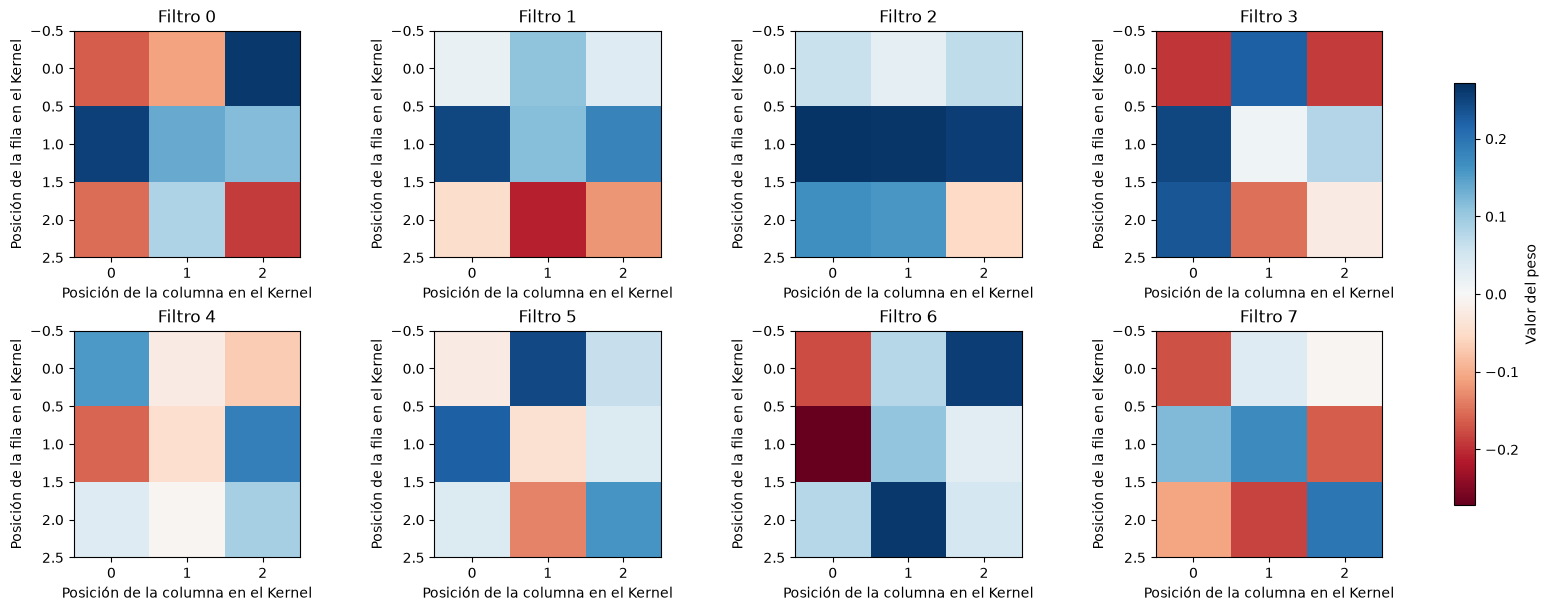

In [57]:
# Convertir cada filtro a forma 3,3
filter_reshape = []
for f in all_filter:
    filter = np.array(f).reshape(3,3)
    filter_reshape.append(filter)

# Encontrar el valor máximo de los pesos
val_max = np.max(np.abs(filter_reshape))

fig, axes = plt.subplots(2, 4, figsize=(16, 6), constrained_layout=True)

for idx, ax in enumerate(axes.flat):
    im = ax.imshow(filter_reshape[idx], cmap="RdBu", vmin=-val_max, vmax=val_max)  # guardamos la referencia en 'im'
    ax.set_title(f"Filtro {idx}")
    ax.set_xlabel("Posición de la columna en el Kernel")
    ax.set_ylabel("Posición de la fila en el Kernel")

fig.colorbar(im, ax=axes, shrink=0.8, label="Valor del peso")

plt.show()  # nota: quitamos tight_layout(), no combina bien con colorbar compartida entre varias subplots

Se observa que por ejemplo para:
- Filtro 0: hay un patrón diagonal. La esquina superior derecha (0,2) y la posición central-izquierda (1,0) son azul oscuro (fuertemente positivas), mientras que la esquina inferior derecha (2,2) es rojo oscuro (fuertemente negativa) y la esquina superior izquierda es rojiza (negativa débil). No es un gradiente vertical puro, sino que podría asociarse a un contraste orientado en diagonal.

- Filtro 1: podría asociarse a un gradiente vertical. Las dos filas superiores son positivas (azul), con la mayor intensidad en la fila del medio (especialmente en la posición izquierda, azul marino oscuro); la fila inferior es negativa (rojo/naranja), con el valor más negativo en el centro.

- Filtro 2: casi toda la fila central es fuertemente positiva (azul oscuro uniforme en las tres posiciones de esa fila), mientras que las filas de arriba y abajo son casi neutras (blanco/pálido). No es un detector de gradiente direccional, responde fuertemente a la fila central de espines, casi sin importar el resto.

- Filtro 3: no presenta un gradiente direccional limpio. Su rasgo más marcado es un valor fuertemente positivo (azul oscuro) en la posición central-izquierda (1,0), rodeado de valores negativos (rojo) en ambas esquinas superiores y en el centro-inferior. El resto de las posiciones son cercanas a cero o positivas débiles. No tiene un patrón claro.

- Filtro 4: se observa que el contraste dominante está en la fila del medio, con un valor fuertemente negativo a la izquierda (1,0) y fuertemente positivo a la derecha (1,2). Podría asociarse a un gradiente horizontal, pero concentrado en esa única fila. Las filas superior e inferior son mucho más débiles y no refuerzan consistentemente la misma dirección.

- Filtro 5: el contraste dominante está en la columna central, con un valor fuertemente positivo arriba (0,1) que se vuelve negativo hacia abajo (2,1) Podría asociarse a un gradiente vertical, pero concentrado en esa columna. 

- Filtro 6: Hay un posible patrón general de gradiente horizontal. La columna izquierda es negativa en conjunto (dominada por el valor más negativo de todo el filtro, en la posición centro-izquierda), mientras que las columnas central y derecha son positivas en conjunto (con dos valores fuertemente positivos: esquina superior derecha y centro-inferior). En general, la parte derecha del kernel es más positiva que la izquierda.

- Filtro 7: No hay un patrón definido.


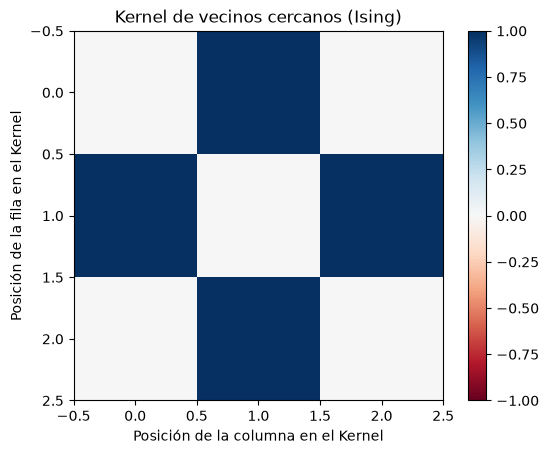

In [40]:
# Kernel de primeros vecinos
kernel_vecinos = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])
plt.imshow(kernel_vecinos, cmap="RdBu", vmin=-1, vmax=1)
plt.title("Kernel de vecinos cercanos (Ising)")
plt.xlabel("Posición de la columna en el Kernel")
plt.ylabel("Posición de la fila en el Kernel")
plt.colorbar()
plt.show()

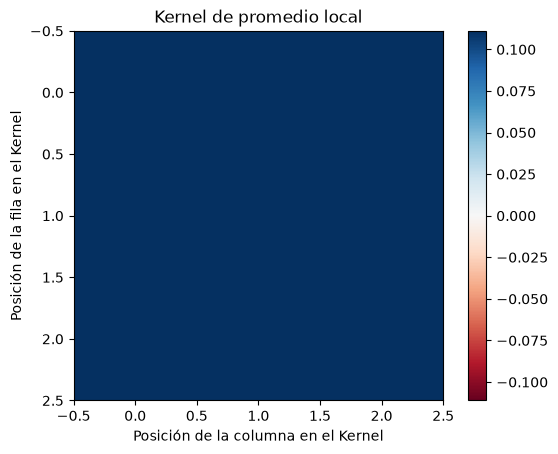

In [41]:
# Kernel de Promedio Local
kernel_promedio = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])
plt.imshow(kernel_promedio, cmap="RdBu", vmin=-1/9, vmax=1/9)
plt.title("Kernel de promedio local")
plt.xlabel("Posición de la columna en el Kernel")
plt.ylabel("Posición de la fila en el Kernel")
plt.colorbar()
plt.show()


Al comparar los 8 filtros aprendidos por la primera capa convolucional con los dos kernels físicos de referencia, no se encuentra una correspondencia clara con ninguno de los dos. El kernel de vecinos cercanos requiere que el centro y las cuatro esquinas sean  cero, y que los cuatro bordes medios compartan el mismo valor entre sí; ningún filtro cumple esta estructura completa, aunque un par de ellos (Filtro 0 y Filtro 6) tienen un centro cercano a cero, sus esquinas conservan valores distintos de cero y sus cuatro bordes no son iguales entre sí. Tampoco se observa el patrón del kernel de promedio local, que exige que los nueve pesos sean iguales y positivos, sin ninguna posición privilegiada. 
Se observa entonces que la red parece haber aprendido basándose en detectores de contraste local orientados en distintas direcciones (vertical, horizontal y diagonal) en lugar de imitar directamente la interacción de primeros vecinos o el cálculo de la magnetización local.


2.  Analiza los mapas de activación de esos filtros sobre una configuración ordenada y una desordenada. ¿La diferencia visual que ves coincide con lo que dirías tú, a ojo, si miraras las dos configuraciones sin saber la respuesta?

Se debe crear un modelo que contenga una sola capa que comparte los mismos pesos ya entrenados de la red original, pero que en vez de dar la probabilidad final, de la salida de la primera capa (conv2d_4), la cual es un mapa de activación por cada uno de los 8.filtros.

In [53]:
# Escoger configuración ordenada y=0 y desordenada y=1
idx_ordenada = np.where(y == 0)[0][0]
idx_desordenada = np.where(y == 1)[0][0]

# Un mapa de activación es el resultado de aplicar un filtro a una imagen, es decir, lo que se ve cuando ese filtro de 3×3 se desliza (hace la convolución) sobre toda una configuración de espines específica
# Construir un submodelo que de una salida intermedia de la primera capa convolucional
# model.layers[0] es la capa conv2d_4 (la primera convolucional)
# .output es el resultado que produce esa capa específica cuando entran los datos, es decir, los 8 mapas de activación. Al usar esto como outputs, se le dice al nuevo modelo que en vez de seguir hasta el final de la red, se detenga aquí y saca lo que sale de esta capa.
entrada = keras.Input(shape=(None, None, 1))
salida_conv1 = model.layers[0](entrada)
modelo_activaciones = keras.Model(inputs=entrada, outputs=salida_conv1)

# Obtener las activaciones
# Toma la configuración ordenada (forma (L,L,1)) y le agrega el eje de "lote" al principio, quedando (1,L,L,1) necesario porque predict() siempre espera un lote, aunque sea de una sola imagen
imagen_ordenada = X[idx_ordenada].reshape(1, L, L, 1)
imagen_desordenada = X[idx_desordenada].reshape(1, L, L, 1)


# Pasa la imagen ordenada por el submodelo (que se detiene después de la primera capa convolucional) y obtiene los 8 mapas de activación
# resultantes, forma (1, L, L, 8)
activaciones_ordenada = modelo_activaciones.predict(imagen_ordenada, verbose=0)
activaciones_desordenada = modelo_activaciones.predict(imagen_desordenada, verbose=0)



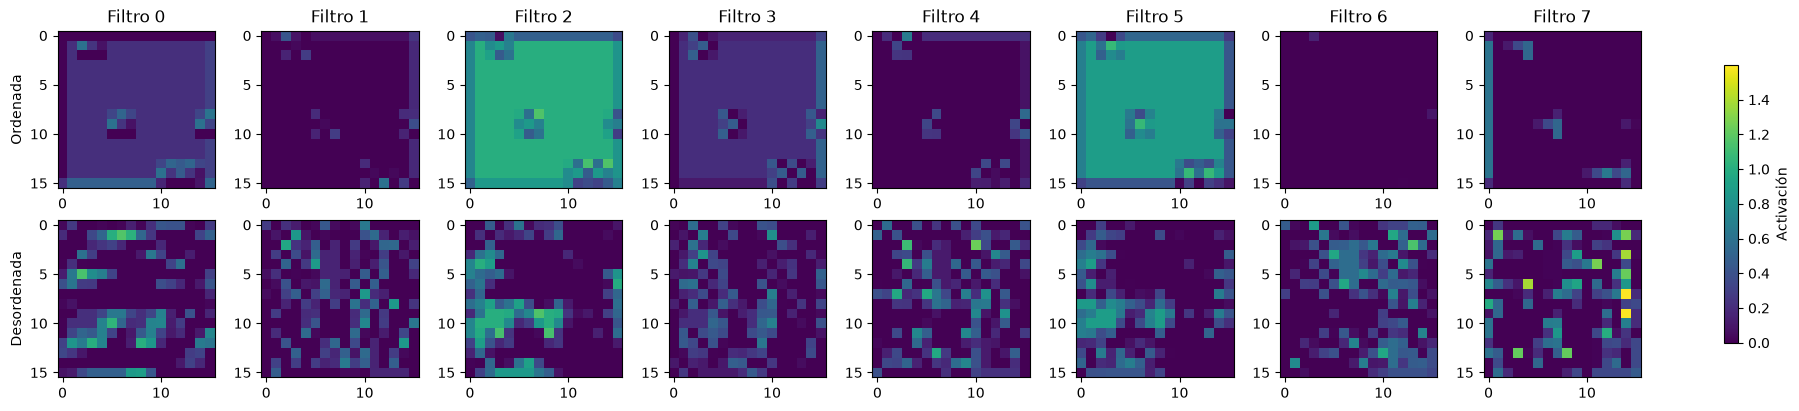

In [56]:
act_ord = activaciones_ordenada[0]      # quita el eje de "lote" → forma (L, L, 8)
act_des = activaciones_desordenada[0]   # lo mismo para la desordenada

val_max_act = np.max([act_ord.max(), act_des.max()])  # máximo compartido entre ambas

fig, axes = plt.subplots(2, 8, figsize=(18, 4), constrained_layout=True)

for canal in range(8):
    im = axes[0, canal].imshow(act_ord[:, :, canal], cmap="viridis", vmin=0, vmax=val_max_act)
    axes[0, canal].set_title(f"Filtro {canal}")

    axes[1, canal].imshow(act_des[:, :, canal], cmap="viridis", vmin=0, vmax=val_max_act)

axes[0, 0].set_ylabel("Ordenada")
axes[1, 0].set_ylabel("Desordenada")

fig.colorbar(im, ax=axes, shrink=0.8, label="Activación")

plt.show()

La anterior figura representa la imágen resultante de aplicar los filtros a una configuración con fase ordenada y desordenada. El resultado es una nueva imágen que indica qué tan fuerte se encontró el patrón que ese filtro está buscando, justo en esa posición.


- Color morado oscuro: representa una activación baja cercana a cero (el filtro casi no reaccionó en esa posición de la imágen)
- Color verde/amarillo: representa una activación alta (el filtro reaccionó en esa posición de la imágen)

Para la fase ordenada el mapa se ve casi en su totalidad oscuro, indicando que los filtros de contraste/borde apenas se activan en casi ninguna posición de la imagen, ya que al estar los espines mayormente alineados entre sí no hay bordes ni contrastes locales para detectar (salvo algunos pocos puntos aislados, correspondientes a espines que no coinciden exactamente con sus vecinos).

Por otro lado, para la fase desordenada, el mapa se ve disperso y con manchas de activación repartidas por toda la imagen, en los 8 filtros por igual, reflejando que en esta fase hay contraste local (espines que difieren de sus vecinos) por todas partes, sin importar la orientación que esté buscando cada filtro.

Dado lo anterior, una configuración ordenada se percibe como un bloque uniforme mayormente de un solo color, mientras que una desordenada se percibe como ruido disperso.

3. Mide qué tan sensible es la red a voltear un solo espín, lejos de $T_c$ y cerca de $T_c$. ¿Dónde es más sensible? ¿Se te ocurre una razón física para eso?

$$S(x) = \frac{1}{L^2}\sum_{i=1}^{L^2} \big|\Delta P_i(x)\big|, \qquad \Delta P_i(x) = P(\text{config. con } s_i \text{ volteado}) - P(x)$$

In [63]:
# Escoger configuración cerca y lejos de Tc
Tc_onsager = 2.269  
idx_cerca = np.argmin(np.abs(T_test - Tc_onsager)) # Devuelve el índice donde la diferencia es mínima
idx_lejos = np.argmax(np.abs(T_test - Tc_onsager)) # Devuelve el índice donde la diferencia es máxima

print(f"Temperatura cerca de Tc {T_test[idx_cerca]}")
print(f"Temperatura lejos de Tc {T_test[idx_lejos]}")

model.evaluate(X_test, y_test, verbose=0)
# Con el modelo, calcular la probabilidad
batch_cerca =X_test[idx_cerca].reshape(1, L, L, 1) # Nuevamente reorganiza los datos en 4 dimensiones: (número de configuraciones, alto, ancho, canales). El -1 se usa cuando no se sabe cuantas configuraciones hay. El 1 se usan cuando ya se sabe
batch_lejos =X_test[idx_lejos].reshape(1, L, L, 1)
# Recordar que model.predic() espera un batch, es decir, una dimensión extra al inicio (1, L, L, 1)
prob_cerca = model.predict(batch_cerca, verbose=0).ravel()
print(f"La probabilidad de que el modelo asigne clase desordenada para una temperatura cerca de Tc es {prob_cerca}"   ) 
prob_lejos = model.predict(batch_lejos, verbose=0).ravel()
print(f"La probabilidad de que el modelo asigne clase desordenada para una temperatura lejos de Tc es {prob_lejos}"   )


Temperatura cerca de Tc 2.6
Temperatura lejos de Tc 3.5
La probabilidad de que el modelo asigne clase desordenada para una temperatura cerca de Tc es [0.99986315]
La probabilidad de que el modelo asigne clase desordenada para una temperatura lejos de Tc es [0.999992]


Ambas temperaturas, T=2.6 y T=3.5, están por encima de Tc=2.269, es decir, que ambas están del lado desordenado de la transición. Entre más lejos estén de Tc estando ya en la fase desordenada, más desordenada es la configuración, y por lo tanto más alta  debería ser la confianza del modelo. Esto se evidencia en el gráfico que se analizó anteriormente, en donde las barras de error se acortan en valores alejados de $T_c$

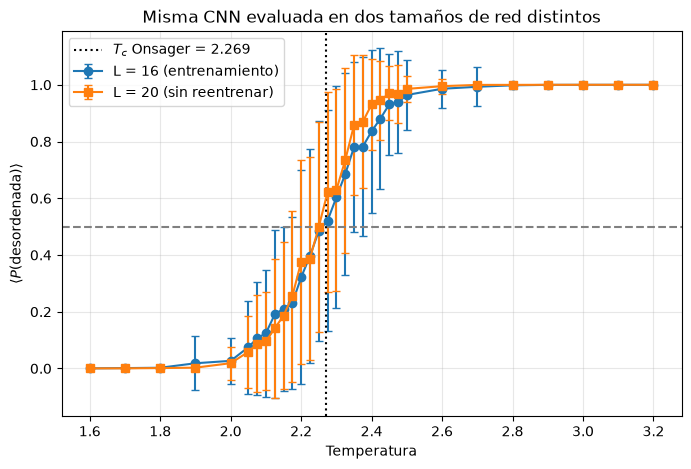


In [64]:
# Verificar lo anterior, pero con una configuración claramente ordenada (T muy por debajo de Tc)
# debería dar una probabilidad cercana a 0, si y=1 representa "desordenada"

batch_ordenada = X_test[np.where(T_test < Tc_onsager)[0][0]].reshape(1, L, L, 1)
prob_ordenada = model.predict(batch_ordenada, verbose=0).ravel()

print("Temperatura usada:", T_test[np.where(T_test < Tc_onsager)[0][0]])
print("Probabilidad de 'desordenada' para esta configuración:", prob_ordenada)

Temperatura usada: 1.9
Probabilidad de 'desordenada' para esta configuración: [0.02895471]


In [65]:
# Para cada posición i (hay L² posiciones en total), tomar la configuración original, voltear únicamente el espín en la posición i 
# (dejando los otros L²-1 espines intactos), y volver a predecir con esa configuración modificada.

x_cerca = X_test[idx_cerca]
x_lejos = X_test[idx_lejos]

copias_x_cerca = []
copias_x_lejos = []
for i in range(L**2):
    copias_x_cerca.append(x_cerca.copy())
    copias_x_lejos.append(x_lejos.copy())
    
#print(copias_x_cerca[0][0])
# Voltear un espín distinto en cada una de esas copias
k=0 # índice para la copia
for i in range(L): # Fija la fila
    for j in range(L): # Fija la columna
        copias_x_cerca[k][i][j] = copias_x_cerca[k][i][j]*(-1)
        copias_x_lejos[k][i][j] = copias_x_lejos[k][i][j]*(-1)
        k = k + 1
        
# Convertir estas listas a arreglos
copias_x_cerca = np.array(copias_x_cerca)
copias_x_lejos = np.array(copias_x_lejos)
#print(copias_x_cerca.shape)

probs_cerca = model.predict(copias_x_cerca, verbose=0)
probs_lejos = model.predict(copias_x_lejos, verbose=0)


In [66]:
# Calcular S(x)
def calcular_S(prob_volteados, prob_real):
    dif = np.abs(prob_volteados - prob_real)
    suma_dif = np.sum(dif)
    S =  suma_dif / len(prob_volteados)     # prob_volteados es el arreglo con las 256 probabilidades
    return S
    
S_cerca = calcular_S(probs_cerca, prob_cerca)
S_lejos = calcular_S(probs_lejos, prob_lejos)

print("S(x) cerca de Tc:", S_cerca)
print("S(x) lejos de Tc:", S_lejos) 


S(x) cerca de Tc: 2.2116816e-05
S(x) lejos de Tc: 7.50646e-07


$S_{cerca}$ ($2.21 \times 10^{-5}$) es mayor que $S_{lejos}$ ($7.51 \times 10^{-7}$) (aproximadamente 30 veces mayor). Es decir, la configuración más cercana a $T_c$ (T=2.6) es mucho más sensible a que se voltee un solo espín que la configuración más lejana (T=3.5)En promedio, un solo espín volteado en la configuración cercana a $T_c$ mueve la probabilidad del modelo alrededor de 30 veces más de lo que la mueve un solo espín volteado en la configuración lejana a $T_c$.

Físicamente, cerca de la transición de fase, el sistema tiene correlaciones de mayor alcance, es decir que un solo espín está más "conectado" con el comportamiento colectivo del resto de la red, así que perturbar uno solo puede desestabilizar más la lectura del modelo sobre la fase completa. Lejos de Tc, la fase está mucho más estable (ya sea completamente ordenada o completamente desordenada) y por tanto, cambiar un solo espín de los 256 es una perturbación insignificante frente a un patrón que ya está fuertemente consolidado, así que la probabilidad casi no se mueve.




4. Verifica si el logit ($z = Wx+b$) final es, en el fondo, una función de la magnetización. Grafica el logit contra $|m(x)|$, antes y después de entrenar. ¿La red "redescubrió" el parámetro de orden por su cuenta, o el resultado depende de trucos de la arquitectura?

In [73]:
# El logit es la salida cruda de la última capa Dense(1), antes de que se le aplique la sigmoide
# Submodelo que contiene todas las capas del modelo entrenado, menos la última (Dense final)
modelo_features = keras.Sequential(model.layers[:-1])

# Obtener las "features" (salida de la penúltima capa) para el conjunto de test
features_test = modelo_features.predict(X_test, verbose=0)
print(features_test.shape)  # debería ser (400, 16) — 400 configuraciones, 16 neuronas

# Pesos de la última capa (Dense final)
W, b = model.layers[-1].get_weights()
print(W.shape, b.shape)  

(400, 16)
(16, 1) (1,)


In [74]:
# Función que calcula logit
def calcular_logit(modelo, X):
    # submodelo con todas las capas de 'modelo' menos la última
    submodelo = keras.Sequential(modelo.layers[:-1])
    
    # obtener las features pasando X (no X_test fijo) por el submodelo
    features = submodelo.predict(X, verbose=0)
    
    # pesos y sesgo de la ÚLTIMA capa de 'modelo' (no de 'model')
    W = modelo.layers[-1].get_weights()[0]
    b = modelo.layers[-1].get_weights()[1]
    
    # Calcular el logit con multiplicación matricial @
    z = features @ W + b
    return z


# Obtener logit
z_test = calcular_logit(model, X_test)
print(z_test.shape)

(400, 1)


In [82]:
## Calcular promedio de los espines en cada configuracion
m_test = np.mean(X_test, axis=(1, 2, 3))   
m_abs_test = np.abs(m_test)                 # valor absoluto, |m(x)|
#
#plt.scatter(m_abs_test, m_test)
#plt.xlabel("|m(x)|")
#plt.ylabel("Logit (z)")
#plt.title("Logit vs. magnetización — modelo entrenado")
#plt.show()

Al graficar el logit ($z$) del modelo entrenado contra $|m(x)|$, se observan dos líneas que divergen. Esto se debe a que el logit no depende realmente del valor absoluto de la magnetización, sino de la magnetización con signo. Para configuraciones con magnetización positiva, el logit crece de forma prácticamente lineal hasta alcanzar $z \approx 1$; para configuraciones con magnetización negativa, el logit decrece de forma igualmente lineal hasta $z \approx -1$. Al usar $|m(x)|$ en el eje horizontal, las dos ramas quedan superpuestas en el mismo rango (0 a 1), produciendo la forma de "V". Es decir que el logit es aproximadamente una función lineal de la magnetización real. Esto muestra que la red, durante el entrenamiento, aprendió por su cuenta la magnetización como variable de decisión, es decir, aprendió a reconstruir internamente el parámetro de orden físico del sistema de Ising, en lugar de basarse en un atajo arbitrario sin relación con la física del problema. La red aprendió a calcular la magnetización neta con signos directamente a partir de los patrones de la imagen de forma linea.

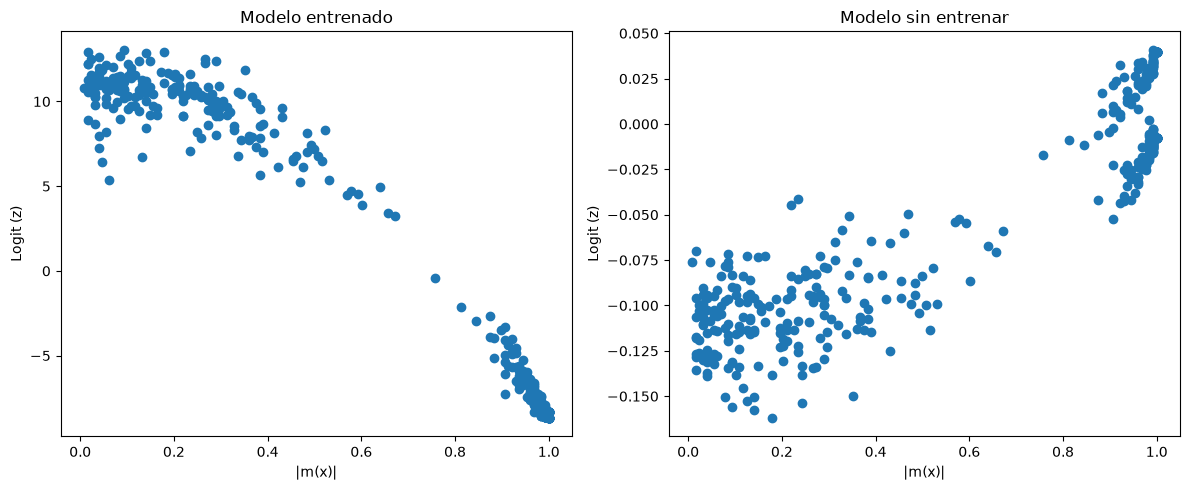

In [89]:
# Modelo con la misma arquitectura, pero sin compilar ni entrenar
keras.utils.set_random_seed(42)  # cualquier número fijo
model_sin_entrenar = keras.Sequential([
    keras.layers.Conv2D(8, (3,3), activation="relu", padding="same", input_shape=(L, L, 1)),
    keras.layers.MaxPooling2D((2,2), padding="same"),
    keras.layers.Conv2D(16, (3,3), activation="relu", padding="same"),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])

# NO se llama a .compile() ni a .fit() y queda con pesos aleatorios iniciales

# Logit con el modelo sin entrenar
z_test_sin_entrenar = calcular_logit(model_sin_entrenar, X_test)

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(m_abs_test, z_test.ravel())
axes[0].set_xlabel("|m(x)|")
axes[0].set_ylabel("Logit (z)")
axes[0].set_title("Modelo entrenado")

axes[1].scatter(m_abs_test, z_test_sin_entrenar.ravel())
axes[1].set_xlabel("|m(x)|")
axes[1].set_ylabel("Logit (z)")
axes[1].set_title("Modelo sin entrenar")

plt.tight_layout()
plt.show()

Esto es lo que entrega la red antes aplicar la sigmoide. Se debe recordar que sigmoide(z) da la probabilidad de desordenada. Si z es muy positivo, la red predice desordenada con alta confianza; si z es muy negativo, predice ordenada con alta confianza; si z≈0, la red está indecisa (P≈0.5).

En este orden de ideas, en el modelo entrenado, cuando $|m(x)|≈0$, es decir, hay configuraciones desordenada, z está siempre alrededor de +10, es decir, la red está muy segura de que es una fase desordenada. Por el contrario, en el modelo sin entrenar, se observa que la escala del eje y toma valores negativos y pequeños y hay una dispersión notoria con respecto al eje de la magnitud de magnetización. Tiene sentido dado que inicialmente, la red tiene pesos aleatorios y por tanto no ha logrado estimar nada.